# DATA reshaping testtt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

oecd_csv = pd.read_csv(r"C:\Users\mathi\OneDrive - University of Copenhagen\7. Semester\BA-Projekt\Data\OECD\FebPwtExport2202024.csv")
oecd_csv.info()

oecd = oecd_csv.pivot_table(
    values="AggValue",
    index="YearCode",
    columns=["RegionCode", "VariableCode"])
oecd.info()
print(type(oecd.index))
print(oecd.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11995 entries, 0 to 11994
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VariableCode  11995 non-null  object 
 1   RegionCode    11995 non-null  object 
 2   YearCode      11995 non-null  int64  
 3   AggValue      11995 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 375.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1950 to 2019
Columns: 190 entries, ('AUS', 'emp') to ('USA', 'rnna')
dtypes: float64(190)
memory usage: 104.5 KB
<class 'pandas.core.indexes.base.Index'>
RegionCode         AUS                                                  \
VariableCode       emp        hc     labsh         rgdpna         rnna   
YearCode                                                                 
1950          3.429873  2.667302  0.680492  127476.031250  569058.8125   
1951          3.523916  2.674344  0.680492  130718.296875  6136

In [6]:
# Generating a (sligthly wider) dataframe, unbalanced panel 
oecd_wide_csv = oecd_csv.pivot_table(index=["YearCode", "RegionCode"], columns="VariableCode", values="AggValue").reset_index()

# Generating 3 new columns based on the 5 newly created columns
# cap_out is Capital (rnna) divided by GDP (rgdpna)
# HC is total human capital, which is human capital per worker (hc) times number of laborers (emp)
# capsh is the share of capital compensation in GDP, which is 1 - labsh, the residual

oecd_wide_csv["cap_out"] = oecd_wide_csv["rnna"] / oecd_wide_csv["rgdpna"]
oecd_wide_csv["HC"] = oecd_wide_csv["hc"] * oecd_wide_csv["emp"]
oecd_wide_csv["capsh"] = 1 - oecd_wide_csv["labsh"]

# log transforming 4 variables
oecd_wide_csv["lnY"] = np.log(oecd_wide_csv["rgdpna"])
oecd_wide_csv["lnK"] = np.log(oecd_wide_csv["rnna"])
oecd_wide_csv["lnH"] = np.log(oecd_wide_csv["HC"])
oecd_wide_csv["lnL"] = np.log(oecd_wide_csv["emp"])

# Generating the unbalanced panel
# wider_cloe60.to_stata(r"C:\Users\mathi\OneDrive - University of Copenhagen\7. Semester\BA-Projekt\Data\OECD\oecd_unbalanced.dta", version=117)

This is actually not needed for analysis, since long format is preferred. 

In [13]:
import matplotlib.pyplot as plt

# Step 1: Data Cleaning
# Check for missing values, doesnt work since these are simply left out of the csv file to start with
missing_values = oecd_csv.isnull().sum()
print("Missing Values:")
print(missing_values)

# We can create a DataFrame with all possible combinations of RegionCode and YearCode and then merge it with your data to identify missing combinations

# Create a DataFrame with all possible combinations of RegionCode and YearCode
all_combinations = pd.DataFrame([(region, year) for region in oecd_csv['RegionCode'].unique() for year in oecd_csv['YearCode'].unique()], columns=['RegionCode', 'YearCode'])

# Merge the all_combinations DataFrame with your data to identify missing combinations
missing_combinations = pd.merge(all_combinations, oecd_csv, on=['RegionCode', 'YearCode'], how='left')
missing_combinations = missing_combinations[missing_combinations['VariableCode'].isnull()]

# Print missing combinations
print("Missing Combinations:")
print(missing_combinations)

oecd1960 = oecd_csv[oecd_csv['YearCode'] >= 1960]

# Group the data by country and year
grouped_data = oecd1960.groupby(['RegionCode'])

# Check if each group contains values for all variables
missing_values = []
for group_name, group_data in grouped_data:
    # Check if all variables are present in the group
    if len(group_data['VariableCode'].unique()) != 5 or group_data["YearCode"].min() >= 1970:
        missing_values.append(group_name[0])

missing_values2 = []

# Print missing combinations of country and year
print("Missing Combinations of Country and Year:")
print(missing_values)


Missing Values:
VariableCode    0
RegionCode      0
YearCode        0
AggValue        0
dtype: int64
Missing Combinations:
      RegionCode  YearCode VariableCode  AggValue
2010         CHL      1950          NaN       NaN
2796         CZE      1953          NaN       NaN
2797         CZE      1954          NaN       NaN
2798         CZE      1955          NaN       NaN
2799         CZE      1956          NaN       NaN
...          ...       ...          ...       ...
11285        SVN      1968          NaN       NaN
11286        SVN      1969          NaN       NaN
11382        SVN      1950          NaN       NaN
11383        SVN      1951          NaN       NaN
11384        SVN      1952          NaN       NaN

[165 rows x 4 columns]
Missing Combinations of Country and Year:
['CZE', 'EST', 'HUN', 'LTU', 'LVA', 'POL', 'SVK', 'SVN']


CHL, GRC is only missing for 1950

KOR is missing for 1950,1951,1952

The Baltic and a big part of eastern european countries are missing from before 1970. 

To achieve a balanced panel, i would have to exclude CZE, EST, HUN, LTU, LVA, POL, SVK, SVN. And possible start it in 1960 to include Greece, South Korea and Chile. 

Furthermore we check whether all countries have 5 variables for each year, and here we also see that CZE, EST, LTU, LVA, SVK, SVN, only have all variables after 1989. 

So to achieve a balanced panel, we would have exclude the previously mentioned countries which would be CZE, EST, HUN, LTU, LVA, POL, SVK, SVN if we choose to start from 1960. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   YearCode    1800 non-null   int64  
 1   RegionCode  1800 non-null   object 
 2   emp         1800 non-null   float64
 3   hc          1800 non-null   float64
 4   labsh       1800 non-null   float64
 5   rgdpna      1800 non-null   float64
 6   rnna        1800 non-null   float64
 7   cap_out     1800 non-null   float64
 8   HC          1800 non-null   float64
 9   capsh       1800 non-null   float64
 10  lnY         1800 non-null   float64
 11  lnK         1800 non-null   float64
 12  lnH         1800 non-null   float64
 13  lnL         1800 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 197.0+ KB
None


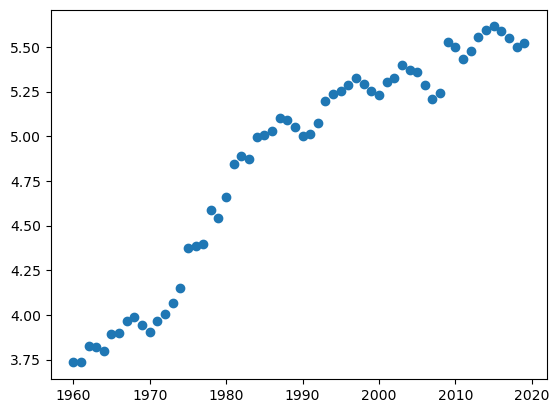

In [14]:
# Here we clean the data from the problematic countries

clean_oecd1960 = oecd1960[~oecd1960['RegionCode'].isin(missing_values)]

# Making the data a bit wider by extracting the VariableCode column

wider_cloe60 = clean_oecd1960.pivot_table(index=["YearCode", "RegionCode"], columns="VariableCode", values="AggValue").reset_index()

# Generating 3 new columns based on the 5 newly created columns
# cap_out is Capital (rnna) divided by GDP (rgdpna)
# HC is total human capital, which is human capital per worker (hc) times number of laborers (emp)
# capsh is the share of capital compensation in GDP, which is 1 - labsh, the residual

wider_cloe60["cap_out"] = wider_cloe60["rnna"] / wider_cloe60["rgdpna"]
wider_cloe60["HC"] = wider_cloe60["hc"] * wider_cloe60["emp"]
wider_cloe60["capsh"] = 1 - wider_cloe60["labsh"]

# log transforming 4 variables
wider_cloe60["lnY"] = np.log(wider_cloe60["rgdpna"])
wider_cloe60["lnK"] = np.log(wider_cloe60["rnna"])
wider_cloe60["lnH"] = np.log(wider_cloe60["HC"])
wider_cloe60["lnL"] = np.log(wider_cloe60["emp"])

wider_cloe60aut = wider_cloe60[wider_cloe60["RegionCode"] == "AUT"]

plt.scatter(wider_cloe60aut["YearCode"], wider_cloe60aut["cap_out"])

print(wider_cloe60.info())

wider_cloe60.to_stata(r"C:\Users\mathi\OneDrive - University of Copenhagen\7. Semester\BA-Projekt\Data\OECD\oecd_balanced.dta", version=117)

In [ ]:
# Check for outliers and inconsistencies
# You may want to visualize the data or compute summary statistics to identify outliers and inconsistencies

# Step 2: Descriptive Analysis
# Summary statistics
summary_stats = oecd_csv.describe()
print("\nSummary Statistics:")
print(summary_stats)

# Visualize trends over time for each variable and region
# You can use libraries like matplotlib or seaborn to create visualizations

# Step 3: Variable Transformation
# Depending on your analysis objectives, you may need to transform variables, create new variables, or aggregate data
# For example, you can calculate average values for each variable across regions and years
average_values = oecd_csv.groupby('Variablecode').agg({'AggValue': 'mean'})
print("\nAverage Values by Variable:")
print(average_values)

# You can also create new variables or perform other transformations based on your analysis needs

# After performing these steps, you can export the cleaned and transformed data to a new CSV file if needed
# data.to_csv("cleaned_data.csv", index=False)  # Uncomment if you want to export the data

# Once the data is prepared, you can import it into Stata for further panel data analysis